In [3]:
# ライブラリをインポートする
import pandas as pd

# csvファイルをデータフレームとして読み込む
df = pd.read_csv("sample_pandas_6 (2).csv")
# 先頭から5行目までを表示する
df.head()

,発注日,商品番号,商品名,単価,在庫,注文数
0,2016-03-06,YY4HAAZR,商品サンプル YY4HAAZR,780,20,24
1,2015-03-27,Z4WOOIYV,商品サンプル Z4WOOIYV,90,45,12
2,2017-05-31,YY4HAAZR,商品サンプル YY4HAAZR,780,10,0
3,2022-10-26,1QJFO8QY,商品サンプル 1QJFO8QY,600,5,24
4,2016-06-10,1QJFO8QY,商品サンプル 1QJFO8QY,600,40,24


In [5]:
category_df = pd.read_csv('category.csv')
category_df

,商品番号,カテゴリー
0,YY4HAAZR,弁当
1,Z4WOOIYV,飲料水
2,1QJFO8QY,弁当
3,MESUDVWQ,菓子類
4,S6RE8W6X,図書・新聞
5,X0ZE2ZMY,飲料水
6,8T7D5DQA,菓子類
7,48XMJXKO,デザート
8,QRMOGNUU,雑貨
9,2HSTCDWM,デザート


In [6]:
df = pd.merge(df, category_df[['商品番号', 'カテゴリー']], how='inner', on='商品番号')
df

,発注日,商品番号,商品名,単価,在庫,注文数,カテゴリー
0,2016-03-06,YY4HAAZR,商品サンプル YY4HAAZR,780,20,24,弁当
1,2015-03-27,Z4WOOIYV,商品サンプル Z4WOOIYV,90,45,12,飲料水
2,2017-05-31,YY4HAAZR,商品サンプル YY4HAAZR,780,10,0,弁当
3,2022-10-26,1QJFO8QY,商品サンプル 1QJFO8QY,600,5,24,弁当
4,2016-06-10,1QJFO8QY,商品サンプル 1QJFO8QY,600,40,24,弁当
...,...,...,...,...,...,...,...
195,2021-08-02,1QJFO8QY,商品サンプル 1QJFO8QY,600,10,42,弁当
196,2019-05-28,X0ZE2ZMY,商品サンプル X0ZE2ZMY,90,45,30,飲料水
197,2015-06-22,48XMJXKO,商品サンプル 48XMJXKO,330,50,36,デザート
198,2022-08-29,QRMOGNUU,商品サンプル QRMOGNUU,420,40,48,雑貨


In [8]:
!pip install pandas matplotlib japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 33.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120306 sha256=fe8d7f56ed1206f395915426871565e157297c61ee001716841d6c7a79848093
  Stored in directory: /root/.cache/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize-matplotlib


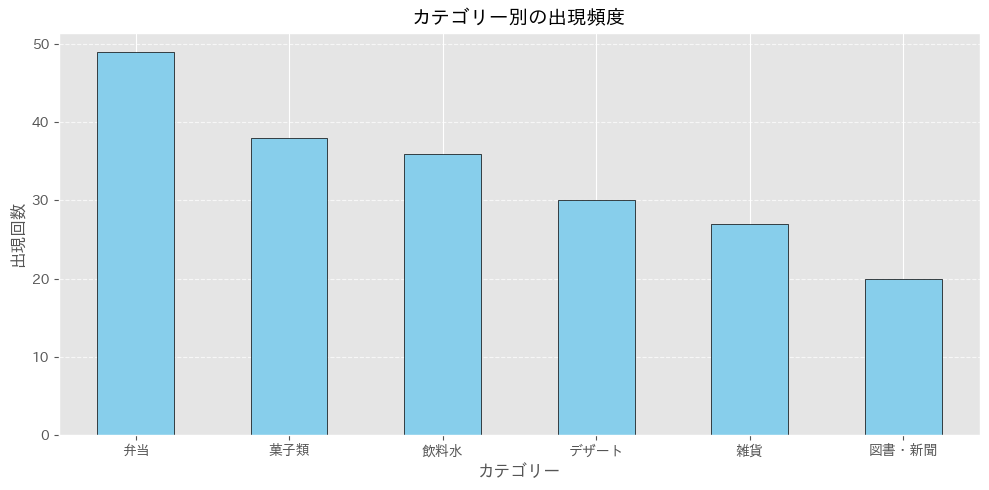

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# 1. データの読み込み（すでにファイルがある前提ですが念のため）
# df = pd.read_csv('sample_pandas_6 (1).csv')

# 2. グラフのスタイル設定
plt.style.use('ggplot')

# 3. カウントして棒グラフ化
df['カテゴリー'].value_counts().plot(
    kind='bar',
    figsize=(10, 5),
    color='skyblue',
    edgecolor='black'
)

# 3. ラベルやタイトルの設定
plt.title('カテゴリー別の出現頻度', fontsize=14)
plt.xlabel('カテゴリー', fontsize=12)
plt.ylabel('出現回数', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [41]:
import pandas as pd

# 1. 注文数の基本統計量を集計し、小数点第一位までに丸める
summary = df.groupby('商品番号')['注文数'].agg(
    注文数='count',
    平均='mean',
    標準偏差='std',
    最小値='min',
    中央値='median',
    最大値='max'
).round(1)

# 結果を表示
print(summary)

          注文数  平均  標準偏差  最小値  中央値  最大値
商品番号                                                
1QJFO8QY      32  35.2      18.5       0    36.0      60
2HSTCDWM      20  29.4      21.1       0    27.0      60
48XMJXKO      10  21.6      13.3       0    21.0      42
8T7D5DQA      21  25.1      18.3       0    36.0      54
MESUDVWQ      17  43.8      18.2       0    48.0      60
QRMOGNUU      27  33.1      16.6       6    36.0      60
S6RE8W6X      20  33.3      21.6       0    39.0      60
X0ZE2ZMY      14  21.9      21.9       0    15.0      60
YY4HAAZR      17  31.8      18.1       0    30.0      60
Z4WOOIYV      22  26.7      19.2       0    24.0      60
